In [52]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# KNN

In [53]:
class KNNRegression:
    def __init__ (self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x in X:
            # Calculate distances to all training points
            distances = np.linalg.norm(self.X_train - x, axis=1)
            
            # Get indices of k nearest neighbors
            k_indices = np.argpartition(distances, self.k)[:self.k]

            # Calculate mean value of k nearest neighbors
            k_nearest_values = self.y_train[k_indices]
            mean_value = np.mean(k_nearest_values)

            predictions.append(mean_value)
        return np.array(predictions)

In [54]:
def scaled_data(X):
    X_scaled = (X - X.min())/(X.max() - X.min())
    return X_scaled

In [55]:
data = pd.read_csv('50_Startups.csv')
data.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [56]:
data = pd.get_dummies(data, columns=['State'], dtype=float)
data.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0.0,0.0,1.0
1,162597.70,151377.59,443898.53,191792.06,1.0,0.0,0.0
2,153441.51,101145.55,407934.54,191050.39,0.0,1.0,0.0
3,144372.41,118671.85,383199.62,182901.99,0.0,0.0,1.0
4,142107.34,91391.77,366168.42,166187.94,0.0,1.0,0.0


In [57]:
X = data[['R&D Spend', 'Administration', 'Marketing Spend', 'State_California', 'State_Florida', 'State_New York']].values
y = data['Profit'].values

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=36)

scaled_data(X_train)
scaled_data(X_test)

print(X_train.shape)
print(X_test.shape)

(40, 6)
(10, 6)


In [59]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    
    mse = (1 / len(X)) * np.sum((y_pred - y)**2)
    rmse = np.sqrt(mse)

    mae = (1 / len(X)) * np.sum(abs(y - y_pred))
    
    y_mean = np.sum(y) / len(y)
    SS_res = np.sum((y - y_pred)**2)
    SS_tot = np.sum((y - y_mean)**2)
    
    r2 = (1 - SS_res/SS_tot)
    return mse, rmse, mae, r2

In [60]:
model = KNNRegression(k=5)
model.fit(X_train, y_train)

In [61]:
mse, rmse, mae, r2 = evaluate(model, X_test, y_test)

print(f'rmse: {rmse}')
print(f'mae: {mae}')
print(f'r2: {r2}')

rmse: 11023.55168427271
mae: 8574.621799999997
r2: 0.8761873963231557


In [62]:
import numpy as np
from sklearn.neighbors import KNeighborsRegressor


sk_model = KNeighborsRegressor(n_neighbors=3)
sk_model.fit(X_train, y_train)
sk_y_pred = sk_model.predict(X_test)

 # Evaluation
print(f'RMSE (Sklearn): {np.sqrt(np.mean(( y_test - sk_y_pred ) ** 2))}')

RMSE (Sklearn): 9580.88525301267


In [63]:
class KNNClassification:
    def __init__(self, k=5):
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.reshape(-1).astype(int)

    def predict(self, X):
        predictions = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            
            k_indices = np.argpartition(distances, self.k - 1)[:self.k]
            k_nearest_labels = self.y_train[k_indices]

            most_common = np.bincount(k_nearest_labels).argmax()
            predictions.append(most_common)

        return np.array(predictions)

In [64]:
data = pd.read_csv('Iris.csv')
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [65]:
data['Species'] = data['Species'].str.strip().str.lower()

data['Species'] = data['Species'].map({
    'iris-setosa': 0,
    'iris-versicolor': 1,
    'iris-virginica': 2
})
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [66]:
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = data['Species'].values 

print(X.shape)

(150, 4)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

X_train = scaled_data(X_train)
X_test = scaled_data(X_test)

print(X_test.shape)

(30, 4)


In [68]:
model = KNNClassification(k=5)
model.fit(X_train, y_train)

In [69]:
def accuracy_classification(model, X, y):
    y_pred = model.predict(X)
    y = y.reshape(-1)
    y_pred = y_pred.reshape(-1)
    return np.mean(y == y_pred)


In [70]:
acc = accuracy_classification(model, X_test, y_test)
print(acc)

1.0


In [71]:
from sklearn . neighbors import KNeighborsClassifier
from sklearn . metrics import accuracy_score

# Scikit - learn model
sk_model = KNeighborsClassifier(n_neighbors =5)
sk_model.fit(X_train, y_train)
sk_y_pred = sk_model.predict(X_test)

# Evaluation
print (f'Accuracy (Sklearn): {accuracy_score(y_test, sk_y_pred)}' )

Accuracy (Sklearn): 1.0


# Decision Tree

In [72]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    
    _, cnt = np.unique(y, return_counts=True)
    p = cnt / len(y)
    return 1 - np.sum(p ** 2)

In [73]:
def entropy(y):
    if len(y)==0:
        return 0
    
    _, cnt = np.unique(y, return_counts=True)
    p = cnt / len(y)

    return -np.sum(p*np.log2(p))

In [74]:
def gini_gain(y, y_left, y_right):
    parent_impurity = gini_impurity(y)
    s_left = gini_impurity(y_left)
    s_right = gini_impurity(y_right)

    weight_left = len(y_left) / len(y)
    weight_right = len(y_right) / len(y)

    gain = parent_impurity - (weight_left * s_left + weight_right * s_right)
    return gain

In [75]:
def information_gain(X, y):
    parent_entropy = entropy(y)

    w = 0
    vals, cnts = np.unique(X, return_counts=True) 
    for v, c in zip(vals, cnts):
        y_sub = y[X==v]
        ratio = c/len(X)
        w += ratio * entropy(y_sub)
    
    gain = parent_entropy - w
    return gain

In [76]:
def best_feature(X, y):
    gains = []
    for i in range(len(X[0])):
        ig = information_gain(X[:,i], y)
        gains.append(ig)
    
    return np.max(gains), np.argmax(gains)

In [77]:
X = np.array([[1, 1], 
              [1, 0], 
              [0, 1], 
              [0, 0]])
y = np.array([1, 1, 0, 0])

In [78]:
f1 = X[:, 0]
f2 = X[:, 1]
f1, f2

(array([1, 1, 0, 0]), array([1, 0, 1, 0]))

In [79]:
gini_f1 = gini_impurity(y)
gini_f2 = gini_impurity(f2)

ig_f1 = information_gain(f1, y)
ig_f2 = information_gain(f2, y)
gini_f1, gini_f2, ig_f1, ig_f2

(np.float64(0.5), np.float64(0.5), np.float64(1.0), np.float64(0.0))

In [80]:
ig, idx = best_feature(X, y)
ig, idx

(np.float64(1.0), np.int64(0))

In [81]:
import numpy as np

class DecisionTreeID3:
    def __init__(self, max_depth=5):
        self.max_depth = max_depth
        self.tree = None

    def _most_common_label(self, y):
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)
    
    def _build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1 or depth == self.max_depth:
            return self._most_common_label(y)
        
        best_gain, best_feature_idx = self._best_split(X, y)
        
        if best_gain == 0:
            return self._most_common_label(y)
        
        feature_values = np.unique(X[:, best_feature_idx])

        children = {} 
        
        for value in feature_values:
            mask = X[:, best_feature_idx] == value
            X_subset = X[mask]
            y_subset = y[mask]

            if len(y_subset) == 0:
                 children[value] = self._most_common_label(y)
            else:
                 children[value] = self._build_tree(X_subset, y_subset, depth + 1)
        
        return best_feature_idx, children
    
    def _best_split(self, X, y):
        gains = []
        for i in range(len(X[0])):
            ig = information_gain(X[:, i], y)
            gains.append(ig)
        
        return np.max(gains), np.argmax(gains)
    
    def predict(self, X):
        predictions = []
        for sample in X:
            node = self.tree
            while isinstance(node, tuple):
                feature_idx, children = node
                feature_value = sample[feature_idx]
                
                if feature_value in children:
                    node = children[feature_value]
                else:
                    node = "Unknown" 
                    break 
                    
            predictions.append(node)
        return np.array(predictions)

In [82]:
def evaluate_model(y_true, y_pred, pos_label='Yes'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    accuracy = np.mean(y_true == y_pred)
    
    tp = np.sum((y_true == pos_label) & (y_pred == pos_label))
    fp = np.sum((y_true != pos_label) & (y_pred == pos_label)) 
    fn = np.sum((y_true == pos_label) & (y_pred != pos_label)) 
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score  = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"Accuracy:  {accuracy * 100:.2f}%")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1 Score:  {f1_score:.2f}")

    return accuracy, precision, recall, f1_score

In [83]:
data = pd.read_csv('PlayTennis.csv')
data.head(20)

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [84]:
X = data[['Outlook', 'Temperature', 'Humidity', 'Wind']].values
y = data['Play Tennis'].values

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, y_train

(array([['Overcast', 'Hot', 'Normal', 'Weak'],
        ['Rain', 'Cool', 'Normal', 'Strong'],
        ['Sunny', 'Cool', 'Normal', 'Weak'],
        ['Overcast', 'Hot', 'High', 'Weak'],
        ['Sunny', 'Hot', 'High', 'Strong'],
        ['Rain', 'Mild', 'High', 'Strong'],
        ['Rain', 'Cool', 'Normal', 'Weak'],
        ['Sunny', 'Mild', 'High', 'Weak'],
        ['Sunny', 'Mild', 'Normal', 'Strong'],
        ['Rain', 'Mild', 'High', 'Weak'],
        ['Overcast', 'Cool', 'Normal', 'Strong']], dtype=object),
 array(['Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'No', 'Yes', 'Yes',
        'Yes'], dtype=object))

In [86]:
model = DecisionTreeID3(max_depth=2)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
evaluate_model(y_test, y_pred)

Accuracy:  100.00%
Precision: 1.00
Recall:    1.00
F1 Score:  1.00


(np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0))

In [87]:
depth = [1, 2, 5, 10]
accuracies = []

for i in depth:
    model = DecisionTreeID3(max_depth=i)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc, prec, rec, f1 = evaluate_model(y_test, y_pred)
    print()
    accuracies.append(acc)

Accuracy:  66.67%
Precision: 1.00
Recall:    0.50
F1 Score:  0.67

Accuracy:  100.00%
Precision: 1.00
Recall:    1.00
F1 Score:  1.00

Accuracy:  100.00%
Precision: 1.00
Recall:    1.00
F1 Score:  1.00

Accuracy:  100.00%
Precision: 1.00
Recall:    1.00
F1 Score:  1.00



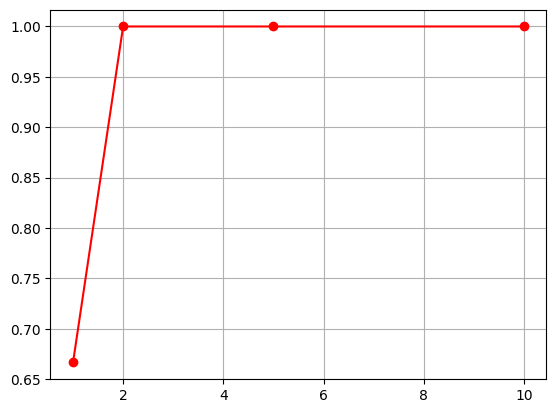

In [88]:
import matplotlib.pyplot as plt

plt.plot(depth, accuracies, marker='o', color='r')
plt.grid()
plt.show()